# 머신러닝 심화 III — 비지도학습(Unsupervised Learning) 튜토리얼
## 차원 축소 · 클러스터링

> Yann LeCun: *"지능이 케이크라면 **비지도학습은 케이크의 시트(빵)**이고, **지도학습은 그 위의 아이싱**이다."*
> — 정답(Y) 없이도 데이터 **구조**를 읽는 힘, 오늘 20문제로 직접 굽습니다.

**학습 목표**
- PCA · t-SNE로 **차원 축소**와 시각화
- K-Means · GMM으로 **군집화** (Hard vs Soft)
- Silhouette · Dunn Index로 **타당성** 정량 평가
- 숨겨둔 정답 레이블과 **교차표**로 최종 해석

**데이터**: Seaborn **`penguins`** (Species는 Q20까지 금지!)
**규칙**: `fig, ax = plt.subplots()` + `sns.*(..., ax=ax)` · Pandas `.loc[]`


---
## Q1~Q3 · 데이터 준비 — 비지도학습 환경 만들기


### Q1. 환경 설정 및 라이브러리 임포트

**"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake."** — Yann LeCun (NIPS 2016 Keynote)

#### 1. 비지도 학습(Unsupervised Learning)의 본질
- **지도 학습 (Supervised Learning):** $(X, Y)$ 쌍을 활용해 정답을 맞히는 알고리즘으로, 전체 AI 생태계에서는 눈에 띄는 **아이싱(Icing)** 역할을 합니다.
- **비지도 학습 (Unsupervised Learning):** 정답 레이블($Y$) 없이 오직 데이터의 입력 특성($X$)만으로 데이터의 내부 표현(Representation), 군집 구조, 이상치 등을 스스로 학습하는 **케이크 시트(Cake Sheet)** 의 토대입니다.
- **실습 목적:** 오늘은 정답 레이블을 일부러 숨긴 채, 알고리즘이 데이터 스스로의 구조를 찾아낼 수 있는지 그 본질을 검증합니다.


In [1]:
import sys

# =====================================================================
# 1. 운영체제별 한글 폰트 설치 (Linux/Colab 환경 대응)
# =====================================================================
# macOS('darwin')가 아닌 리눅스(예: 구글 코랩) 환경일 때만 나눔 폰트를 설치합니다.
if sys.platform != 'darwin':
    # -qq 옵션으로 로그를 숨기고, 2>/dev/null로 에러 메시지를 제외한 설치를 조용히 진행합니다.
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    # 시스템 폰트 캐시를 갱신하여 설치된 폰트를 인식시킵니다.
    !fc-cache -fv 2>/dev/null
    # Matplotlib의 기존 폰트 캐시를 삭제하여 새로운 폰트가 정상 적용되도록 합니다.
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# =====================================================================
# 2. 필수 데이터 과학 및 비지도 학습 라이브러리 임포트
# =====================================================================
# 기본 수치 연산 및 데이터 처리
import numpy as np
import pandas as pd

# 시각화 및 폰트 관리
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 수학적 거리 계산 (군집 분석 시 거리 측정용)
from scipy.spatial.distance import pdist, cdist

# Scikit-Learn: 전처리 및 차원 축소
from sklearn.preprocessing import StandardScaler  # 데이터 스케일 표준화 (평균 0, 분산 1)
from sklearn.decomposition import PCA             # 주성분 분석 (선형 차원 축소)
from sklearn.manifold import TSNE                 # t-SNE (시각화용 비선형 차원 축소)

# Scikit-Learn: 군집화(Clustering) 알고리즘
from sklearn.cluster import KMeans                # 거리 기반 k-Means 군집화
from sklearn.mixture import GaussianMixture       # 확률 분포 기반 가우시안 혼합 모델(GMM)

# Scikit-Learn: 군집 평가 지표
from sklearn.metrics import silhouette_score, silhouette_samples # 군집 응집도 및 분리도 평가 (실루엣 점수)

# 경고 메시지 제어
import warnings
warnings.filterwarnings('ignore') # 분석 흐름을 방해하는 불필요한 경고(Warning) 메시지를 무시합니다.

# =====================================================================
# 3. Matplotlib에 한글 폰트 등록 및 시각화 기본 설정
# =====================================================================
# 리눅스 시스템 경로와 macOS 기본 폰트 경로에서 폰트 파일을 찾아 Matplotlib 시스템에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# 그래프 전역 스타일 설정
plt.rcParams.update({
    'font.family': 'NanumBarunGothic', # 한글 깨짐 방지를 위해 나눔바른고딕으로 지정
    'axes.unicode_minus': False,       # 마이너스(-) 기호가 네모나 깨진 문자로 나오는 현상 방지
    'figure.dpi': 110,                 # 선명한 그래프 확인을 위해 해상도(DPI) 조정
})

# Seaborn 테마 및 한글 폰트 일괄 적용
sns.set_theme(style='whitegrid', font='NanumBarunGothic',
              rc={'axes.unicode_minus': False})

# =====================================================================
# 4. 분석 재현성을 위한 난수 시드 고정
# =====================================================================
# k-Means의 초기 중심점 설정 등 무작위성이 포함된 알고리즘의 결과를 항상 동일하게 유지합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('비지도학습 실습 환경 준비 완료')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

### Q2. Seaborn `penguins` 로드 및 탐색

**[문제 제시]**
Seaborn 내장 **`penguins`** 데이터셋을 불러옵니다.

- 344마리 펭귄, **3종**(Adelie / Chinstrap / Gentoo)
- 수치형: 부리 길이·깊이, 날개 길이, 몸무게
- **Species**는 나중에 '정답지'로만 사용 — 지금은 보지 않습니다!

참고: Palmer Penguins 프로젝트 — [Horst et al.](https://allisonhorst.github.io/palmerpenguins/)

In [2]:
penguins = sns.load_dataset('penguins')

print(f"shape: {penguins.shape}")
print(f"\n컬럼: {list(penguins.columns)}\n")
print(f"결측치:\n{penguins.isnull().sum()}\n")
display(penguins.head())

shape: (344, 7)

컬럼: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

결측치:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Q3. 전처리 · 정답 레이블(Species) 분리 — 완전한 비지도 환경

**[문제 제시]**
**비지도학습 환경**을 만듭니다.

1. 결측 행 제거 (`.loc` 필터)
2. **`y_true`** (Species)를 별도 보관 → **금고에 잠금**
3. **`X`** = 수치형 4개 특성만 — 알고리즘은 Y를 모릅니다!

> "정답 없이 군집을 찾아라!" — 이것이 오늘의 게임 규칙입니다.

In [4]:
import pandas as pd

# 1. 결측치 제거
df = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']).reset_index(drop=True)

# 2. y_true (Species) 별도 보관 (금고에 잠금)
y_true = df['species']

# 3. X = 수치형 4개 특성만 추출
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features]

# 데이터 정보 출력
print(f"X shape: {X.shape}")
print(f"종류 수 (정답, 확인용): {y_true.nunique()}")
display(X.describe())

X shape: (342, 4)
종류 수 (정답, 확인용): 3


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


---
## Q4~Q7 · PCA — 분산 보존 차원 축소


### Q4. PCA와 스케일링 — 왜 StandardScaler가 필수인가?

**[문제 제시]**
**PCA (Principal Component Analysis)** 는 데이터 **분산(Variance)** 을 최대 보존하는 **직교 기저**를 찾습니다.

- 1주성분 PC1 = 분산이 가장 큰 방향
- 2주성분 PC2 = PC1에 수직이면서 다음으로 분산이 큰 방향

**스케일링 필수**: `body_mass_g`(수천 g) vs `bill_depth_mm`(수 mm) — 스케일 안 맞으면 **무거운 특성 하나**가 PCA를 지배합니다.

Pearson (1901) · Hotelling (1933) 등 고전 통계학의 핵심 기법.

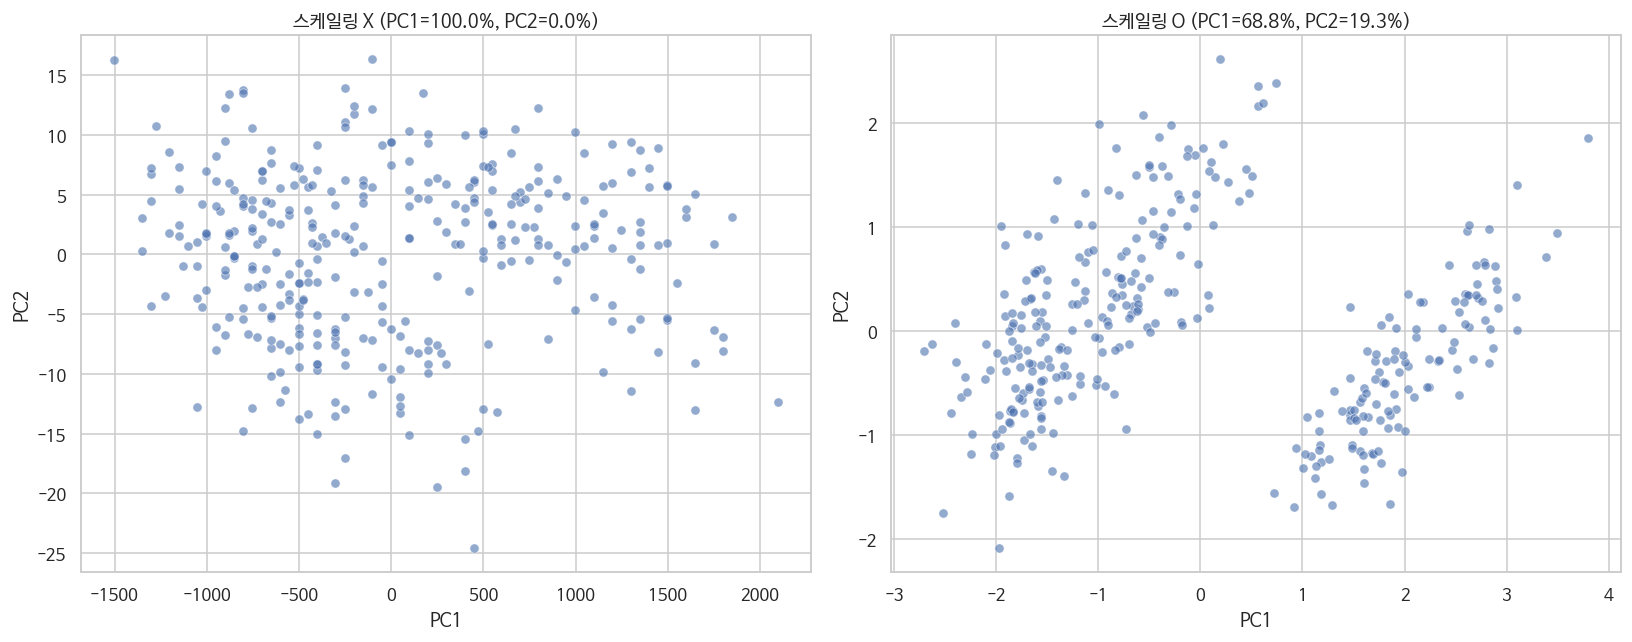

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. 스케일링을 하지 않은 경우의 PCA
pca_unscaled = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_unscaled = pca_unscaled.fit_transform(X)
var_unscaled = pca_unscaled.explained_variance_ratio_

# 2. 스케일링을 한 경우의 PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)
var_scaled = pca_scaled.explained_variance_ratio_

# 시각화 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 스케일링 X
sns.scatterplot(x=X_pca_unscaled[:, 0], y=X_pca_unscaled[:, 1], alpha=0.6, ax=ax1)
ax1.set_title(f'스케일링 X (PC1={var_unscaled[0]:.1%}, PC2={var_unscaled[1]:.1%})')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# 오른쪽: 스케일링 O
sns.scatterplot(x=X_pca_scaled[:, 0], y=X_pca_scaled[:, 1], alpha=0.6, ax=ax2)
ax2.set_title(f'스케일링 O (PC1={var_scaled[0]:.1%}, PC2={var_scaled[1]:.1%})')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Q5. StandardScaler 적용

**[문제 제시]**
`StandardScaler`: 각 특성을 **평균 0, 분산 1**로 변환합니다.

`.loc`로 DataFrame 형태를 유지하며 스케일링합니다.

In [6]:
from sklearn.preprocessing import StandardScaler

# 1. StandardScaler 객체 생성
scaler = StandardScaler()

# 2. .loc를 사용하여 DataFrame 형태 유지하며 스케일링 수행
X_scaled_df = X.copy()
X_scaled_df.loc[:, features] = scaler.fit_transform(X[features])

# 결과 확인 (평균 0, 분산 1 확인)
print("스케일링 후 평균 (≈0):")
print(X_scaled_df.mean().round(4))

print("\n스케일링 후 표준편차 (≈1):")
print(X_scaled_df.std().round(4))

display(X_scaled_df.head())

스케일링 후 평균 (≈0):
bill_length_mm       0.0
bill_depth_mm       -0.0
flipper_length_mm   -0.0
body_mass_g          0.0
dtype: float64

스케일링 후 표준편차 (≈1):
bill_length_mm       1.0015
bill_depth_mm        1.0015
flipper_length_mm    1.0015
body_mass_g          1.0015
dtype: float64


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,-1.324737,1.089724,-0.563715,-0.938776
4,-0.847812,1.748985,-0.777373,-0.689020


### Q6. PCA 적합 — 주성분과 설명 분산

**[문제 제시]**
전체 4개 주성분에 대한 **Explained Variance Ratio** 를 확인합니다.

- **차원의 저주**: 고차원에서 거리·밀도 개념이 왜곡 (Bellman, 1961)
- PCA: 정보 손실을 **분산 기준**으로 최소화하며 차원 축소

In [7]:
from sklearn.decomposition import PCA

# 1. 전체 특성 수(4개)만큼 주성분 분석 수행
pca_full = PCA(n_components=len(features), random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled_df[features])

# 2. 설명 분산 비율 확인
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

# 3. 결과 DataFrame 생성 및 출력
pca_result_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(features))],
    'explained_variance_ratio': exp_var_ratio,
    'cumulative': cum_var_ratio
})

display(pca_result_df.round(4))

# 2차원 축소 데이터 shape 확인 (시각화용 준비)
print(f"\n2D PCA 좌표 shape: {X_pca_full[:, :2].shape}")

,PC,explained_variance_ratio,cumulative
0,PC1,0.6884,0.6884
1,PC2,0.1931,0.8816
2,PC3,0.0913,0.9729
3,PC4,0.0271,1.0000



2D PCA 좌표 shape: (342, 2)


### Q7. 누적 설명 분산(Explained Variance) 시각화

**[문제 제시]**
Scree plot 스타일 — **각 PC 기여도**와 **누적 곡선**을 함께 봅니다.

'몇 개 PC까지 유지할까?' — 실무에서 차원 선택의 1차 기준.

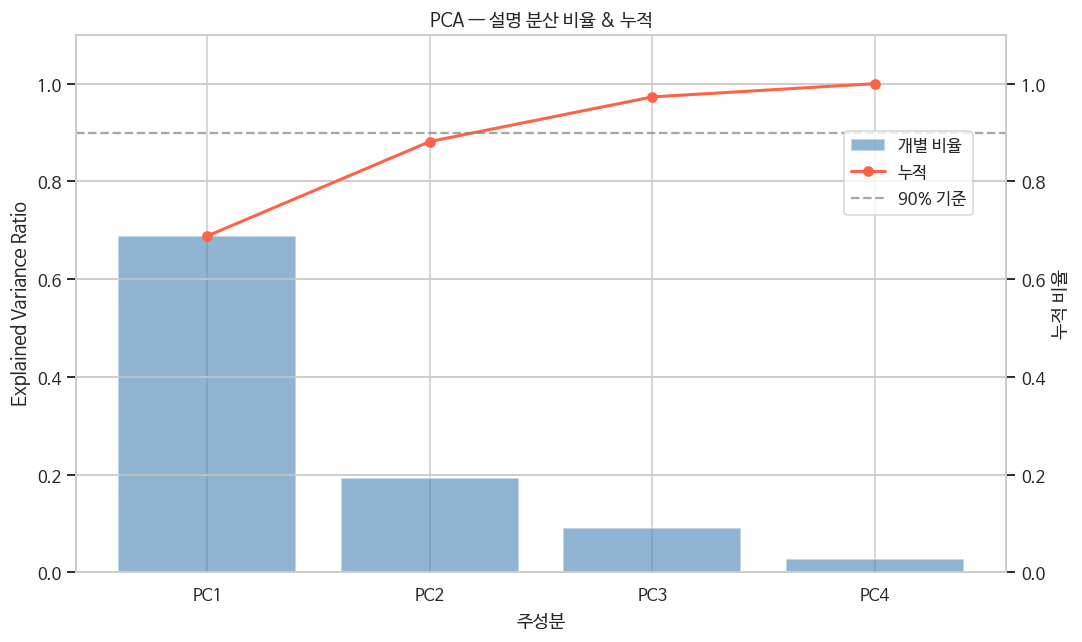

PC1+PC2 누적 설명 분산: 88.2%


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화 데이터 준비 (앞선 Q6의 결과 사용)
pc_labels = pca_result_df['PC']
exp_var = pca_result_df['explained_variance_ratio']
cum_var = pca_result_df['cumulative']

# 2. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(10, 6))

# 개별 주성분 기여도 (막대 그래프)
ax1.bar(pc_labels, exp_var, alpha=0.6, color='steelblue', label='개별 비율')
ax1.set_xlabel('주성분')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_ylim(0, 1.1)

# 누적 기여도 (선 그래프, 보조축 사용)
ax2 = ax1.twinx()
ax2.plot(pc_labels, cum_var, marker='o', color='tomato', linewidth=2, label='누적')
ax2.set_ylabel('누적 비율')
ax2.set_ylim(0, 1.1)

# 90% 기준선 표시
ax2.axhline(y=0.9, color='gray', linestyle='--', alpha=0.7, label='90% 기준')

# 타이틀 및 범례
plt.title('PCA — 설명 분산 비율 & 누적')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.8))

plt.tight_layout()
plt.show()

print(f"PC1+PC2 누적 설명 분산: {cum_var[1]:.1%}")

---
## Q8~Q10 · t-SNE — 비선형 시각화 & PCA 비교


### Q8. t-SNE 이론 — Maaten & Hinton (2008)

**[문제 제시]**
**t-SNE** (t-Distributed Stochastic Neighbor Embedding)

- 논문: van der Maaten & Hinton (2008) — [Journal of Machine Learning Research](https://www.jmlr.org/papers/v9/vandermaaten08a.html)
- 고차원 **유사도(거리)** 를 저차원 **t-분포**로 매핑 — **비선형** 구조 보존에 강함
- **한계**: (1) **새 데이터 transform 불가** — fit한 데이터만 시각화 (2) perplexity·학습률에 민감 (3) 전역 거리는 신뢰 X, **국소 구조** 위주

> PCA = **선형** · 전역 분산 | t-SNE = **비선형** · 군집 시각화

In [9]:
from sklearn.manifold import TSNE

# 1. t-SNE 객체 생성 및 학습
# n_components=2 (시각화용), perplexity=30 (표준값), learning_rate='auto'로 설정
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled_df)

# 2. 결과 출력
print(f"t-SNE 결과 데이터 shape: {X_tsne.shape}")
print(f"KL divergence (최종 오차 값): {tsne.kl_divergence_:.4f}")

t-SNE 결과 데이터 shape: (342, 2)
KL divergence (최종 오차 값): 0.3733


### Q9. t-SNE 2D 시각화

**[문제 제시]**
클러스터 **색 없이** (비지도!) t-SNE 좌표만 scatter 합니다.

정답 레이블 없이도 **데이터 덩어리**가 보이면, 비지도학습이 구조를 읽고 있다는 신호입니다.

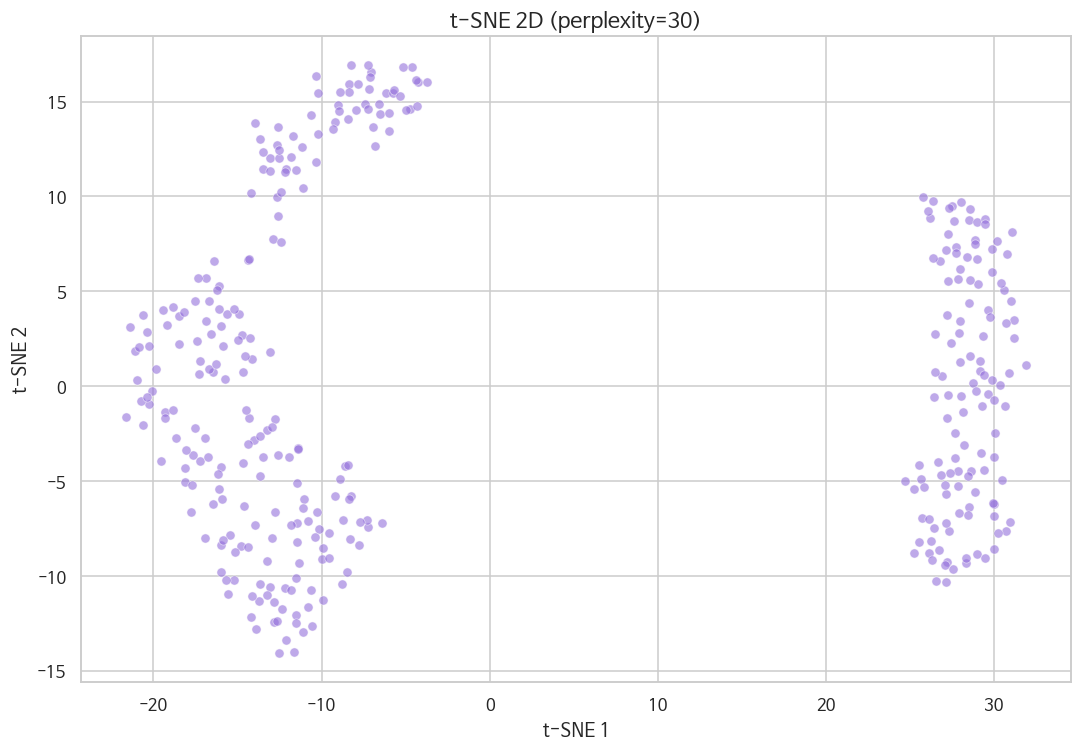

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 설정
fig, ax = plt.subplots(figsize=(10, 7))

# 2. t-SNE 결과 산점도 그리기 (색상 지정 없이 단일 색상으로)
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    alpha=0.6,
    color='mediumpurple',
    ax=ax
)

# 3. 레이블 및 타이틀 설정
ax.set_title('t-SNE 2D (perplexity=30)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

### Q10. PCA vs t-SNE — 나란히 비교

**[문제 제시]**
**직관적·시각적 비교**:
- PCA: 축이 **분산** 방향 — 해석 가능 (loadings)
- t-SNE: **군집 분리**가 더 선명할 수 있음 — 해석은 어려움

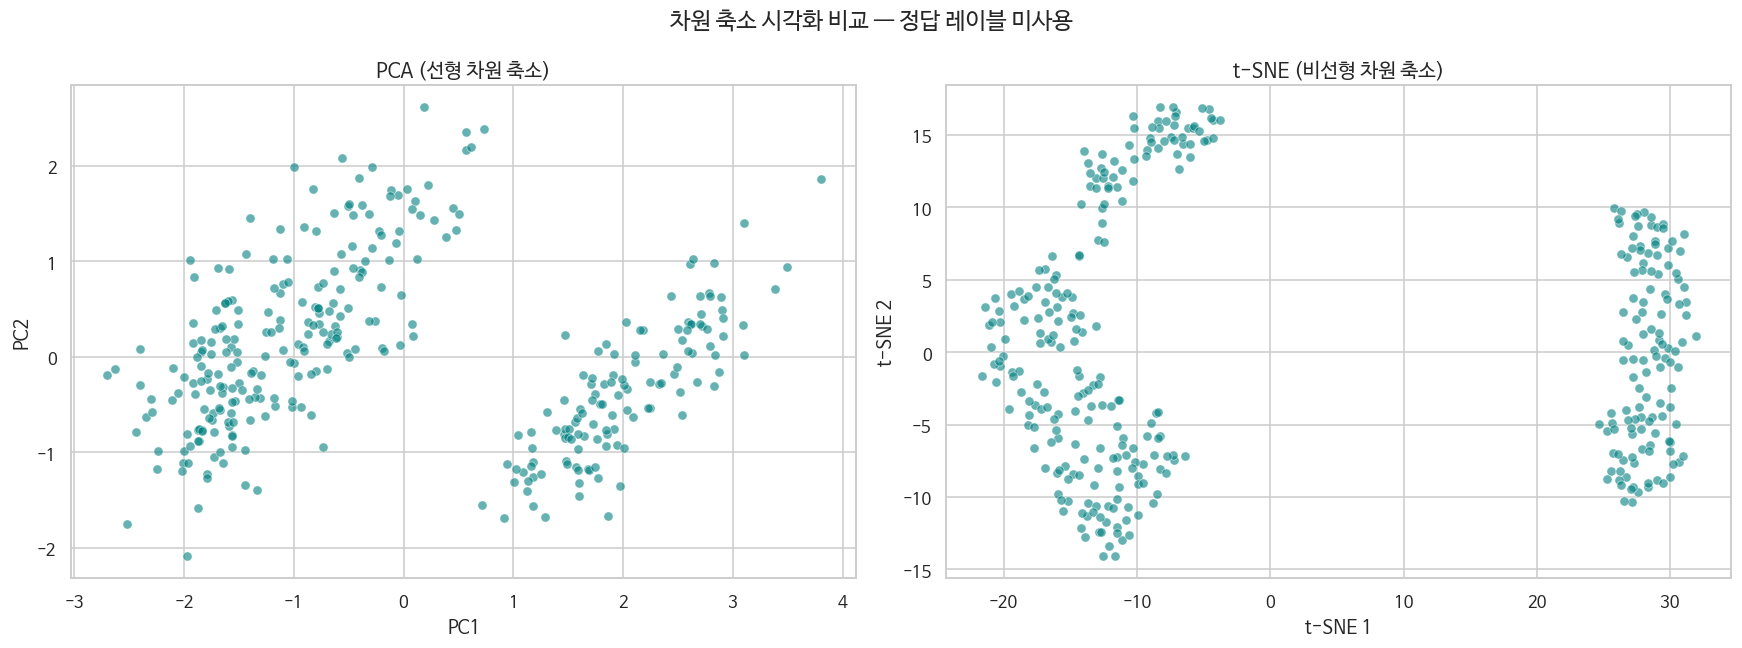

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 영역 설정
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. PCA 시각화 (선형 축소)
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    alpha=0.6,
    color='teal',
    ax=ax1
)
ax1.set_title('PCA (선형 차원 축소)', fontsize=13)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# 3. t-SNE 시각화 (비선형 축소)
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    alpha=0.6,
    color='teal',
    ax=ax2
)
ax2.set_title('t-SNE (비선형 차원 축소)', fontsize=13)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.suptitle('차원 축소 시각화 비교 — 정답 레이블 미사용', fontsize=15)
plt.tight_layout()
plt.show()

---
## Q11~Q14 · K-Means — Elbow & 최적 K


### Q11. K-Means — Hard Clustering 개념

**[문제 제시]**
**K-Means** (Lloyd, 1982; MacQueen, 1967)

1. K개 중심(centroid) 초기화
2. 각 점 → 가장 가까운 중심에 **할당**
3. 중심 → 클러스터 평균으로 **갱신**
4. 수렴까지 반복

**Hard Clustering**: 각 점은 **하나의** 클러스터에만 속함.

**한계**: (1) K를 미리 정해야 함 (2) **구형(spherical)** 분포에 강함 — 길쭉한·중첩된 군집에 약함 (3) 초기값·지역 최적

In [14]:
K_RANGE = range(2, 11)
inertias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

inertia_df = pd.DataFrame({'K': list(K_RANGE), 'inertia': inertias})
print(inertia_df)

    K     inertia
0   2  565.707645
1   3  379.392503
2   4  300.399536
3   5  232.604895
4   6  204.392600
5   7  187.028921
6   8  170.980041
7   9  158.995983
8  10  149.362787


### Q12. Elbow Method — 반복문으로 Inertia 수집

**[문제 제시]**
**Elbow Method**: Inertia vs K 그래프에서 **팔꿈치** 지점 = 적절한 K 후보.

수학적으로는 **Bias-Variance** trade-off의 직관적 버전 — K가 너무 크면 과적합(각 점≈1 cluster).

In [15]:
# Q11에서 이미 수집 — K별 inertia 확인
for _, row in inertia_df.iterrows():
    print(f"K={int(row['K']):2d}  inertia={row['inertia']:.1f}")

K= 2  inertia=565.7
K= 3  inertia=379.4
K= 4  inertia=300.4
K= 5  inertia=232.6
K= 6  inertia=204.4
K= 7  inertia=187.0
K= 8  inertia=171.0
K= 9  inertia=159.0
K=10  inertia=149.4


In [17]:
from sklearn.cluster import KMeans

# K 범위 설정 (2부터 10까지)
K_RANGE = range(2, 11)
inertias = []

# K값에 따른 K-Means 적합 및 inertia 수집
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# 결과 출력을 위한 데이터프레임 생성
inertia_df = pd.DataFrame({'K': list(K_RANGE), 'inertia': inertias})

# 결과 확인
print("K값에 따른 Inertia 변화:")
display(inertia_df)

K값에 따른 Inertia 변화:


,K,inertia
0,2,565.707645
1,3,379.392503
2,4,300.399536
3,5,232.604895
4,6,204.392600
5,7,187.028921
6,8,170.980041
7,9,158.995983
8,10,149.362787


### Q13. Elbow Method 시각화

**[문제 제시]**
`fig, ax = plt.subplots()` + line plot으로 Elbow curve.

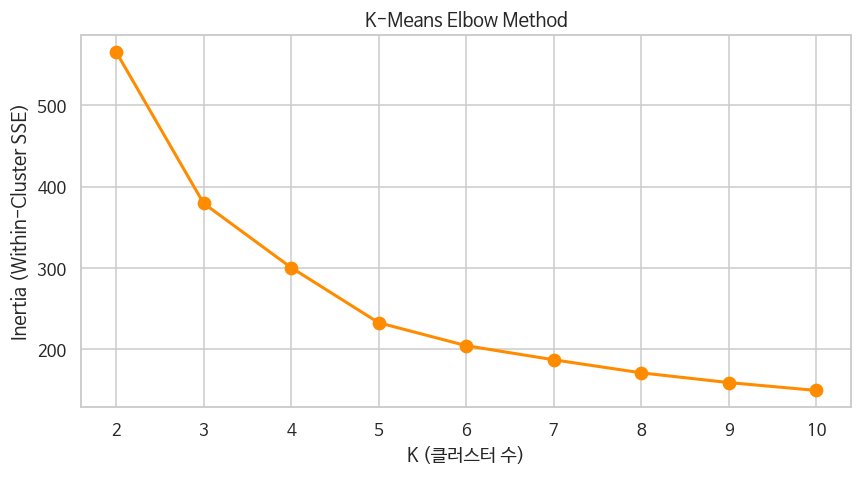

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(inertia_df['K'], inertia_df['inertia'], 'o-', color='darkorange', linewidth=2, markersize=8)
ax.set_xlabel('K (클러스터 수)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('K-Means Elbow Method')
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.show()


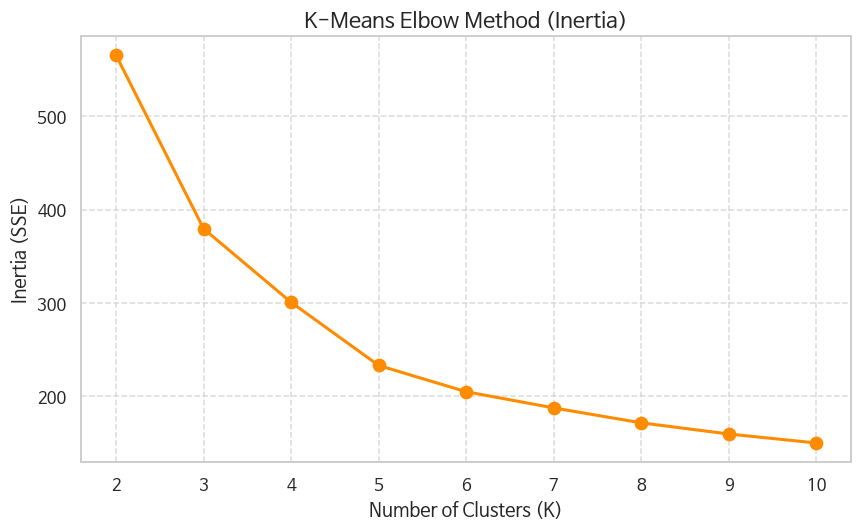

In [18]:
import matplotlib.pyplot as plt

# Elbow Method 시각화
fig, ax = plt.subplots(figsize=(8, 5))

# K값에 따른 Inertia 변화를 선 그래프로 표현
ax.plot(inertia_df['K'], inertia_df['inertia'], marker='o', linestyle='-', color='darkorange', linewidth=2, markersize=8)

# 그래프 레이블 및 타이틀 설정
ax.set_title('K-Means Elbow Method (Inertia)', fontsize=14)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Inertia (SSE)', fontsize=12)
ax.set_xticks(list(K_RANGE))
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Q14. 최적 K로 K-Means 군집화 및 시각화

**[문제 제시]**
Elbow + 도메인 지식으로 **`OPTIMAL_K = 3`** 선택 후 최종 군집화.

PCA 2D 평면에 **클러스터 ID**를 색으로 표시 (여전히 Species 정답은 사용 안 함).

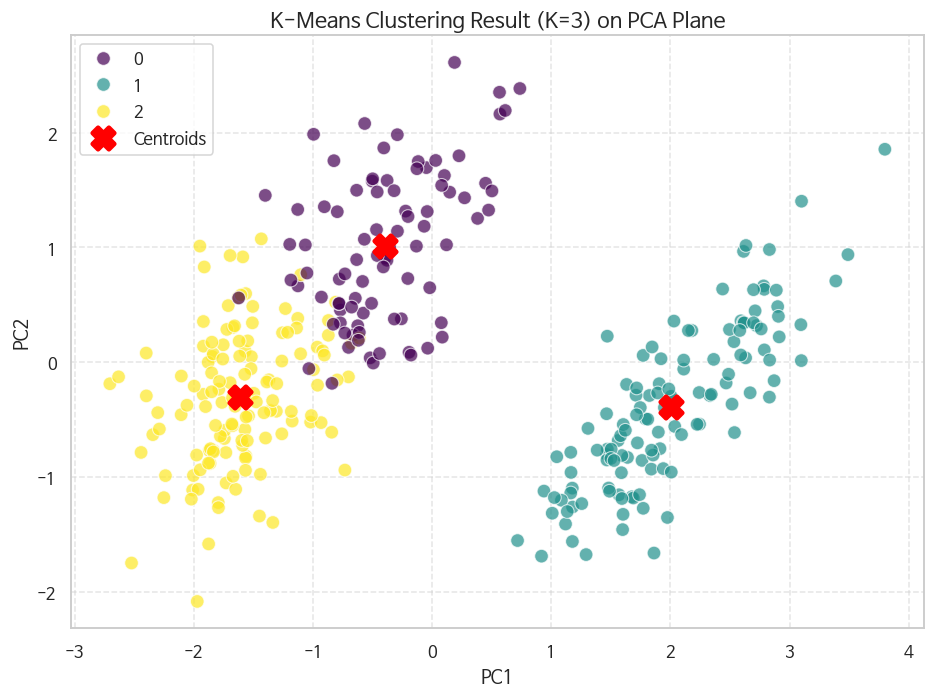

클러스터별 샘플 수:
0     87
1    123
2    132
Name: count, dtype: int64


In [19]:
# 1. 최적의 K 설정 및 K-Means 모델 생성
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)

# 2. 군집화 수행 (학습 및 예측)
clusters = kmeans.fit_predict(X_scaled)

# 3. 결과 시각화를 위해 PCA 데이터에 클러스터 할당
# X_pca_full의 앞쪽 2개 주성분(PC1, PC2) 사용
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    hue=clusters,
    palette='viridis',
    alpha=0.7,
    edgecolor='w',
    s=80
)

# 4. 클러스터 중심점(Centroids) 시각화
# 중심점도 PCA 공간으로 변환해야 함
centroids_pca = pca_full.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    linewidths=3,
    color='red',
    label='Centroids'
)

plt.title(f'K-Means Clustering Result (K={OPTIMAL_K}) on PCA Plane', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 클러스터별 샘플 수 확인
print("클러스터별 샘플 수:")
print(pd.Series(clusters).value_counts().sort_index())

---
## Q15~Q17 · 클러스터링 타당성 — Silhouette & Dunn Index


### Q15. Silhouette Score — Rousseeuw (1987)

**[문제 제시]**
**Silhouette Score** (Rousseeuw, 1987, J. Comput. Appl. Math.)

각 샘플 $i$에 대해:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$: 같은 클러스터 내 **평균 거리** (응집도)
- $b(i)$: **가장 가까운** 타 클러스터까지 평균 거리 (분리도)
- $s(i) \in [-1, 1]$ — **1에 가까울수록** 잘 군집됨

**정답 레이블 없이** 클러스터 품질을 평가하는 대표 지표.

In [20]:
from sklearn.metrics import silhouette_score

silhouette_avg = []

# K값에 따른 실루엣 지수 계산
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

# 결과 데이터프레임 생성
silhouette_df = pd.DataFrame({'K': list(K_RANGE), 'silhouette': silhouette_avg})

# 결과 출력
print("K값에 따른 Silhouette Score 변화:")
display(silhouette_df.round(4))

# 최고점 K 확인
best_k = silhouette_df.loc[silhouette_df['silhouette'].idxmax(), 'K']
print(f"\nSilhouette 최고 K: {int(best_k)}")

K값에 따른 Silhouette Score 변화:


,K,silhouette
0,2,0.5315
1,3,0.4472
2,4,0.3996
3,5,0.3789
4,6,0.3680
5,7,0.3309
6,8,0.2961
7,9,0.2834
8,10,0.2846



Silhouette 최고 K: 2


### Q16. Silhouette Score 막대 그래프 시각화

**[문제 제시]**
K별 Silhouette를 **bar chart**로 비교합니다.

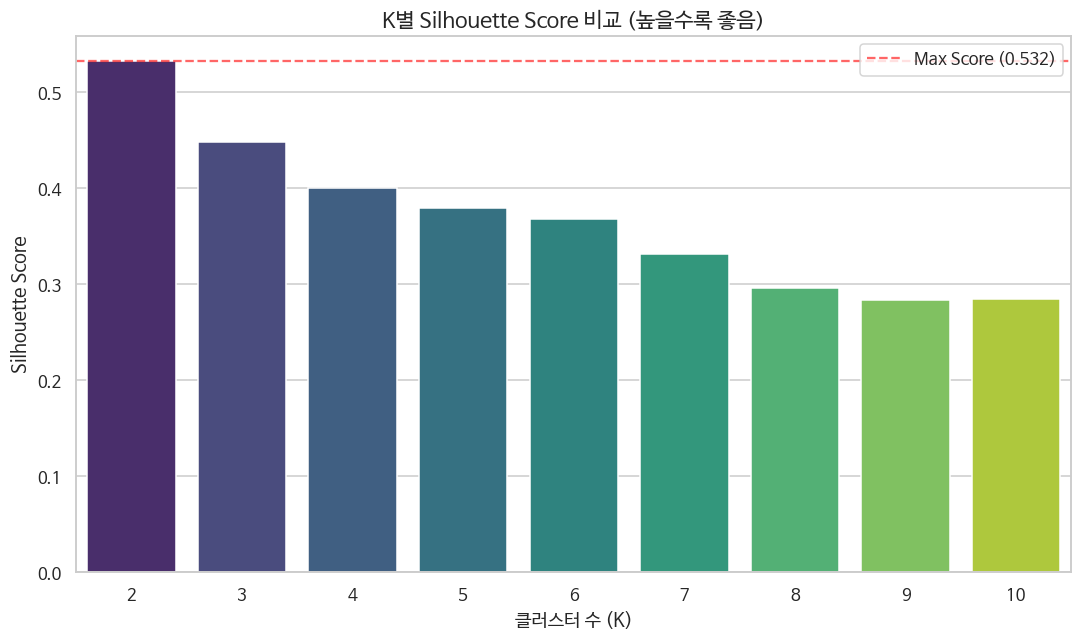

In [21]:
# 1. 시각화 영역 설정
fig, ax = plt.subplots(figsize=(10, 6))

# 2. K별 실루엣 지수 막대 그래프
sns.barplot(
    x='K',
    y='silhouette',
    data=silhouette_df,
    palette='viridis',
    ax=ax
)

# 3. 최고점 강조 및 기준선
best_idx = silhouette_df['silhouette'].idxmax()
best_val = silhouette_df['silhouette'].max()
ax.axhline(y=best_val, color='red', linestyle='--', alpha=0.6, label=f'Max Score ({best_val:.3f})')

# 4. 타이틀 및 레이블
ax.set_title('K별 Silhouette Score 비교 (높을수록 좋음)', fontsize=14)
ax.set_xlabel('클러스터 수 (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

### Q17. Dunn Index — 군집 간·군집 내 거리 비율

**[문제 제시]**
**Dunn Index** (Dunn, 1974)

$$DI = \frac{\min_{i \neq j} \delta(C_i, C_j)}{\max_k \Delta(C_k)}$$

- 분자: **클러스터 간** 최소 거리 (멀리 떨어져 있을수록 ↑)
- 분모: **클러스터 내** 최대 직경 (빽빽할수록 ↓)
- **값이 클수록** 군집화 품질 ↑

sklearn 미제공 → 직접 구현해 K별 비교.

K값에 따른 Dunn Index 변화:


,K,dunn_index
0,2,0.2722
1,3,0.0572
2,4,0.0687
3,5,0.0636
4,6,0.0667
5,7,0.0667
6,8,0.0667
7,9,0.0607
8,10,0.0667


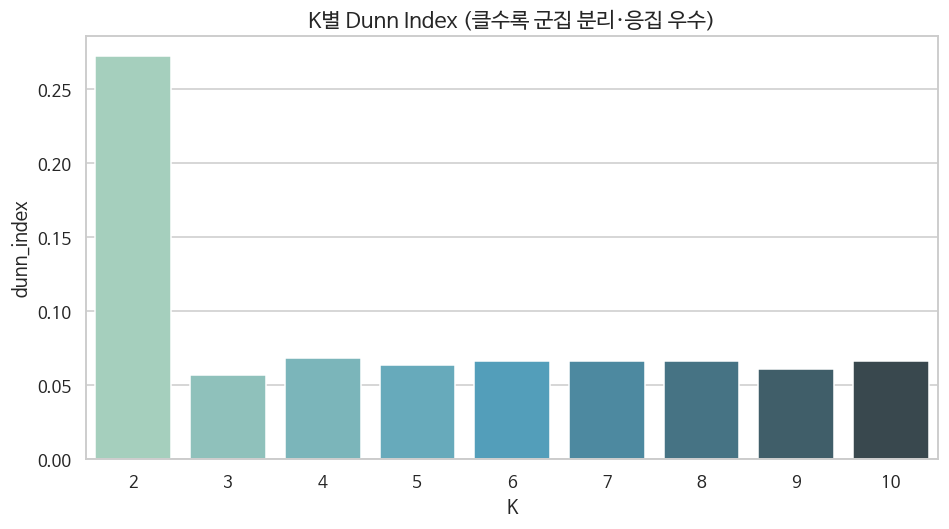

In [22]:
from scipy.spatial.distance import pdist, squareform

def calculate_dunn_index(X, labels):
    # 각 데이터 포인트 간의 거리 행렬 계산
    distances = squareform(pdist(X))

    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # 1. Intra-cluster distance (군집 내 거리의 최댓값 - Diameter)
    max_intra_dist = 0
    for k in unique_clusters:
        cluster_points = distances[labels == k][:, labels == k]
        if cluster_points.size > 0:
            max_intra_dist = max(max_intra_dist, cluster_points.max())

    # 2. Inter-cluster distance (군집 간 거리의 최솟값)
    min_inter_dist = np.inf
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = distances[labels == unique_clusters[i]][:, labels == unique_clusters[j]]
            if cluster_i.size > 0:
                min_inter_dist = min(min_inter_dist, cluster_i.min())

    return min_inter_dist / max_intra_dist if max_intra_dist != 0 else 0

dunn_scores = []

# K값에 따른 Dunn Index 계산
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = calculate_dunn_index(X_scaled, labels)
    dunn_scores.append(score)

# 결과 데이터프레임 생성
dunn_df = pd.DataFrame({'K': list(K_RANGE), 'dunn_index': dunn_scores})

print("K값에 따른 Dunn Index 변화:")
display(dunn_df.round(4))

# 최고점 시각화 (막대 그래프)
plt.figure(figsize=(10, 5))
sns.barplot(x='K', y='dunn_index', data=dunn_df, palette='GnBu_d')
plt.title('K별 Dunn Index (클수록 군집 분리·응집 우수)', fontsize=14)
plt.show()

---
## Q18~Q19 · GMM — Soft Clustering vs K-Means


### Q18. GMM (Gaussian Mixture Model) — Soft Clustering

**[문제 제시]**
**GMM**: 데이터가 **K개 가우시안**의 **혼합**으로 생성되었다고 가정.

**EM 알고리즘** (Dempster, Laird & Rubin, 1977):
- **E-step**: 각 점이 각 가우시안에 속할 **확률( responsibility )** 계산
- **M-step**: 가중 평균으로 **평균·공분산·혼합 비율** 갱신

**Soft Clustering**: 한 점이 Cluster 0에 70%, Cluster 1에 30% — **확률**로 소속.

K-Means ≈ GMM(구형, hard)의 특수한 경우.

In [24]:
gmm = GaussianMixture(n_components=OPTIMAL_K, random_state=RANDOM_STATE, n_init=5)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_proba = gmm.predict_proba(X_scaled)

print('GMM BIC:', round(gmm.bic(X_scaled), 1))
print('GMM AIC:', round(gmm.aic(X_scaled), 1))
print('\n첫 5개 샘플 소속 확률:')
proba_df = pd.DataFrame(gmm_proba, columns=[f'C{i}' for i in range(OPTIMAL_K)])
print(proba_df.head().round(3))


GMM BIC: 2553.6
GMM AIC: 2384.9

첫 5개 샘플 소속 확률:
      C0   C1     C2
0  1.000  0.0  0.000
1  0.999  0.0  0.001
2  0.976  0.0  0.024
3  1.000  0.0  0.000
4  1.000  0.0  0.000


K값에 따른 GMM 성능 지표 (AIC, BIC):


,K,AIC,BIC
0,2,2475.59,2586.80
1,3,2384.88,2553.62
2,4,2374.49,2600.74
3,5,2376.94,2660.71
4,6,2376.32,2717.62
5,7,2379.84,2778.66
6,8,2378.50,2834.85
7,9,2370.22,2884.08
8,10,2395.98,2967.36


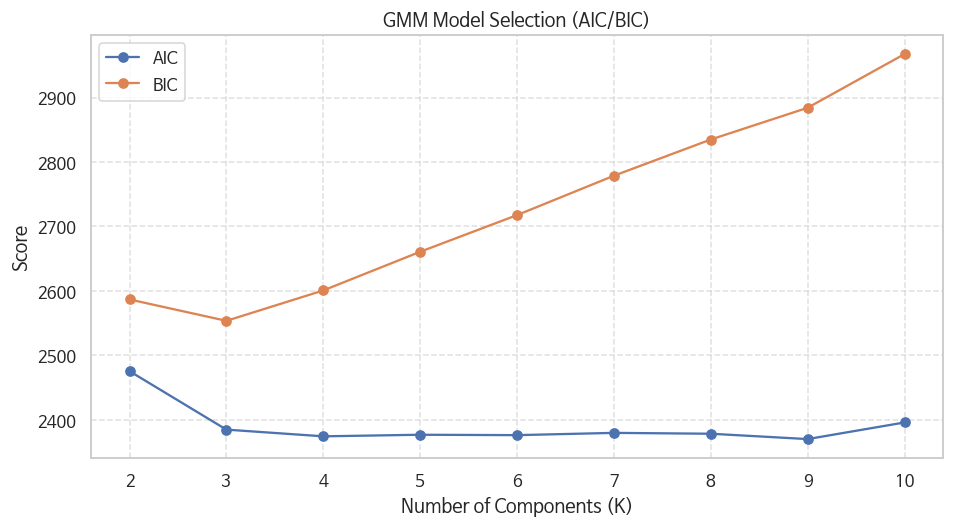

In [23]:
from sklearn.mixture import GaussianMixture

aics = []
bics = []

# K값에 따른 GMM 적합 및 AIC/BIC 수집
for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=10)
    gmm.fit(X_scaled)
    aics.append(gmm.aic(X_scaled))
    bics.append(gmm.bic(X_scaled))

# 결과 데이터프레임 생성
gmm_perf_df = pd.DataFrame({
    'K': list(K_RANGE),
    'AIC': aics,
    'BIC': bics
})

print("K값에 따른 GMM 성능 지표 (AIC, BIC):")
display(gmm_perf_df.round(2))

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(K_RANGE, aics, label='AIC', marker='o')
plt.plot(K_RANGE, bics, label='BIC', marker='o')
plt.title('GMM Model Selection (AIC/BIC)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

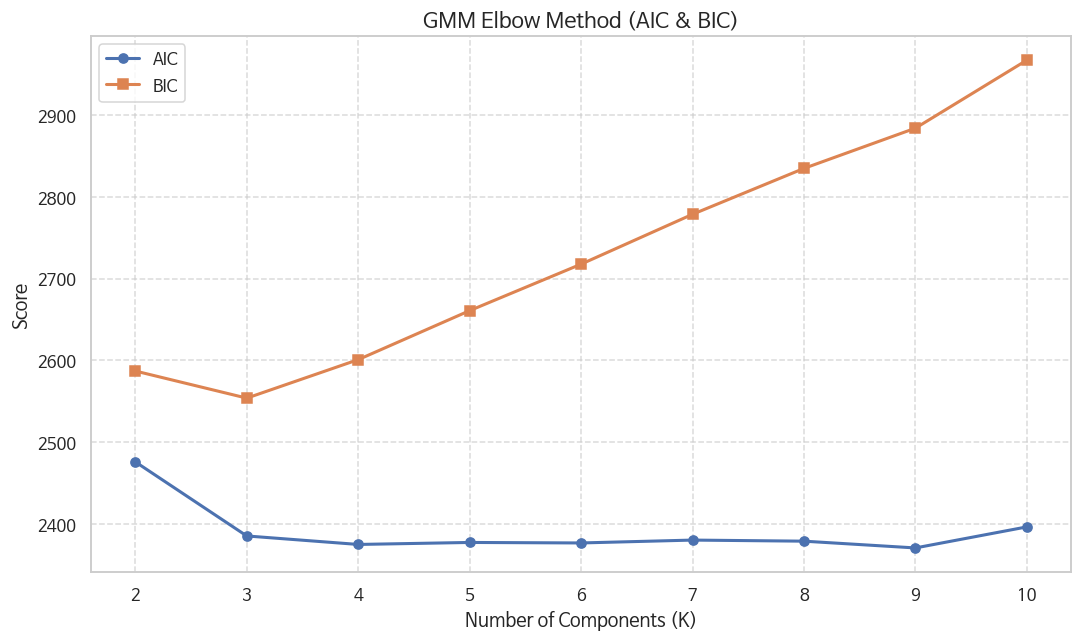

In [25]:
# GMM AIC/BIC Elbow Chart 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# AIC와 BIC 선 그래프 그리기
ax.plot(gmm_perf_df['K'], gmm_perf_df['AIC'], marker='o', label='AIC', linewidth=2)
ax.plot(gmm_perf_df['K'], gmm_perf_df['BIC'], marker='s', label='BIC', linewidth=2)

# 그래프 스타일 설정
ax.set_title('GMM Elbow Method (AIC & BIC)', fontsize=14)
ax.set_xlabel('Number of Components (K)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(list(K_RANGE))
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### Q19. GMM vs K-Means — 결과 비교 시각화

**[문제 제시]**
같은 K=3, 같은 PCA 평면 — **Hard(K-Means)** vs **Soft(GMM)** 할당 비교.

일치율(adjusted rand는 정답 없이도 pure clustering agreement — 여기서는 두 방법 간 일치)도 확인.

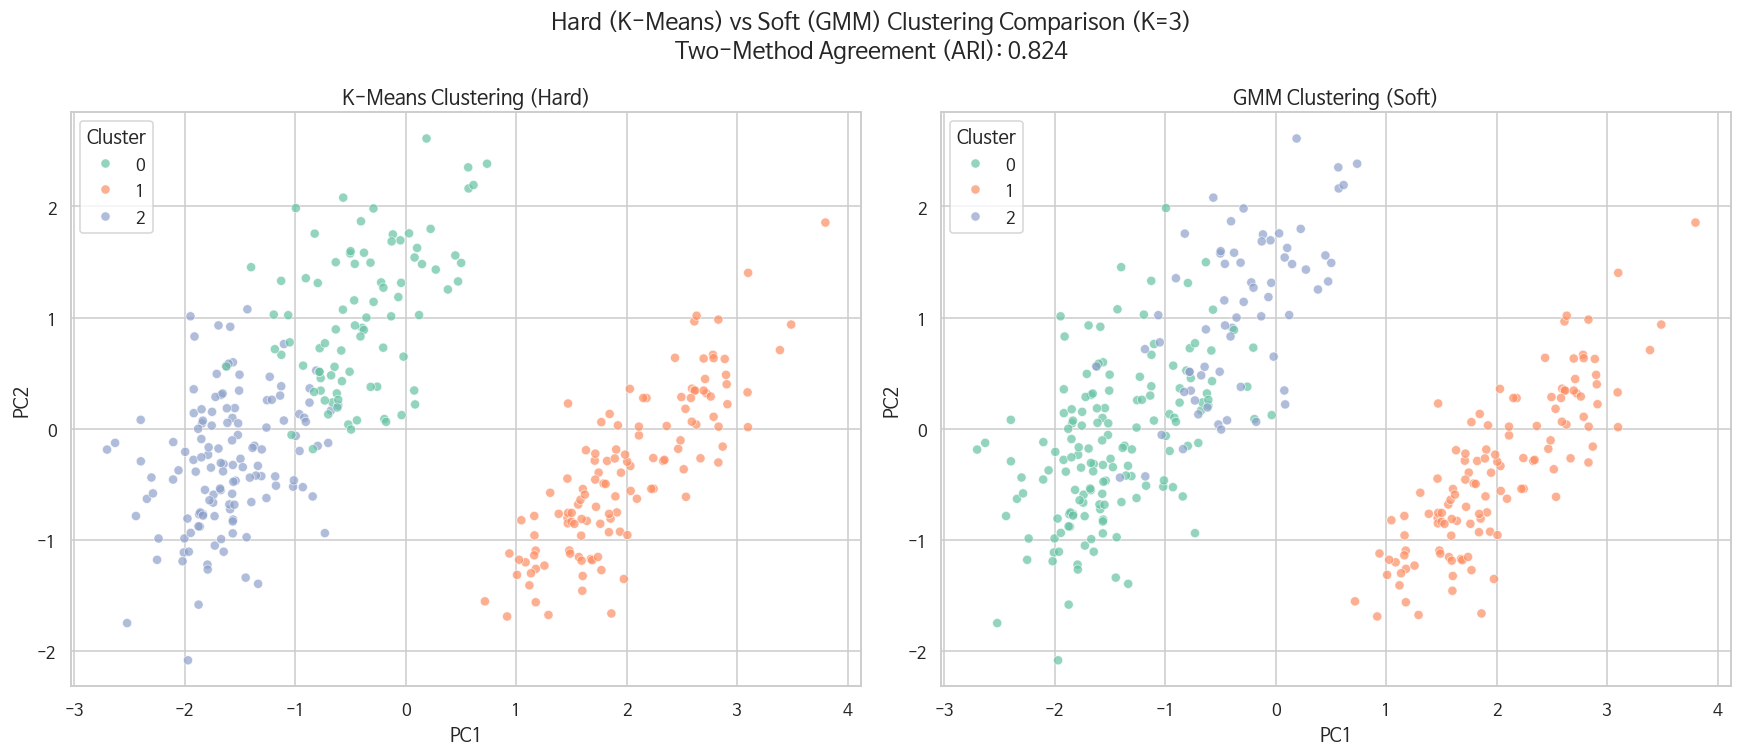

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

# 1. 시각화 영역 설정 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 2. K-Means 결과 시각화 (Hard Clustering)
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    hue=clusters,
    palette='Set2',
    ax=ax1,
    alpha=0.7
)
ax1.set_title('K-Means Clustering (Hard)', fontsize=13)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(title='Cluster')

# 3. GMM 결과 시각화 (Soft -> Hard predict)
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    hue=gmm_labels,
    palette='Set2',
    ax=ax2,
    alpha=0.7
)
ax2.set_title('GMM Clustering (Soft)', fontsize=13)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(title='Cluster')

# 4. 두 방식 간의 일치도 (Adjusted Rand Index)
ari_val = adjusted_rand_score(clusters, gmm_labels)

plt.suptitle(f'Hard (K-Means) vs Soft (GMM) Clustering Comparison (K=3)\nTwo-Method Agreement (ARI): {ari_val:.3f}', fontsize=15)
plt.tight_layout()
plt.show()

K-Means vs GMM Adjusted Rand Index: 0.824


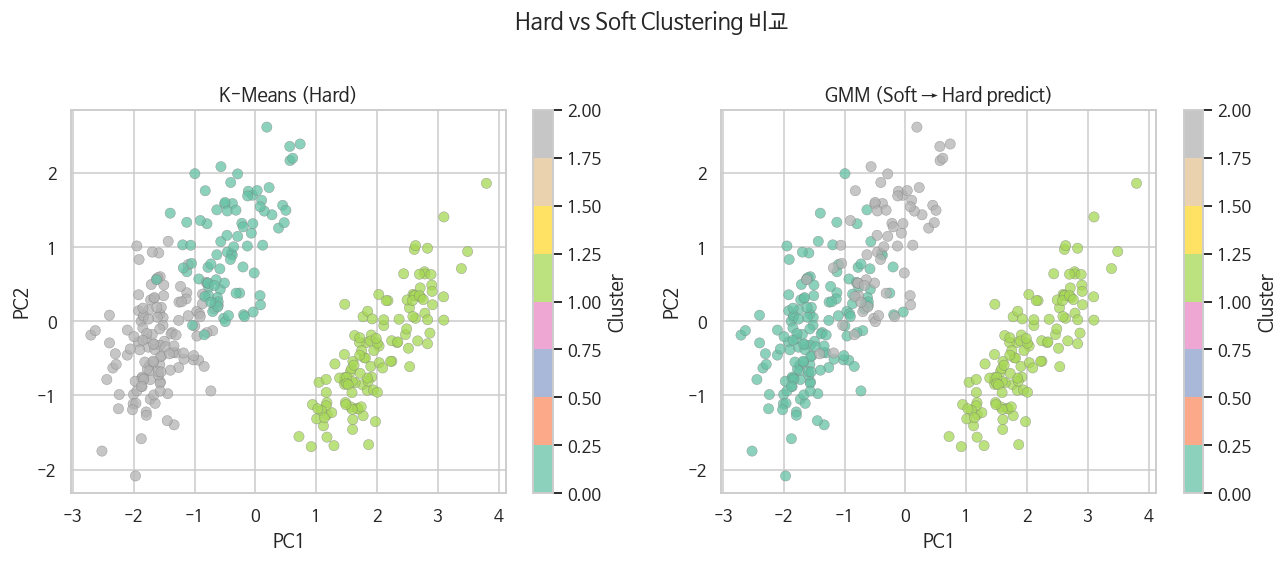

In [ ]:
# 코드

---
## Q20 · 정답 레이블과 매핑 — 비지도학습 최종 해석


### Q20. 금고에서 꺼낸 Species — Crosstab 최종 해석

**[문제 제시]**
드디어 **`y_true`(Species)** 를 꺼냅니다!

- **Crosstab**: 행=실제 종, 열=예측 클러스터
- **Adjusted Rand Index (ARI)**: 정답 vs 클러스터 **일치도** [-1, 1]
- **Normalized Mutual Information (NMI)**: 정보 이론 기반 일치

> "비지도학습이 **정답 없이** 찾은 구조가, 실제 **생물학적 종**과 얼마나 맞을까?" — 오늘의 최종 보스전.

=== K-Means vs True Species Crosstab ===


K-Means Cluster,0,1,2
True Species,,,
Adelie,24,0,127
Chinstrap,63,0,5
Gentoo,0,123,0



=== GMM vs True Species Crosstab ===


GMM Cluster,0,1,2
True Species,,,
Adelie,149,0,2
Chinstrap,3,0,65
Gentoo,0,123,0



=== Clustering Performance Evaluation ===


,Metric,K-Means,GMM
0,ARI (Adjusted Rand Index),0.793,0.960
1,NMI (Normalized Mutual Info),0.786,0.935


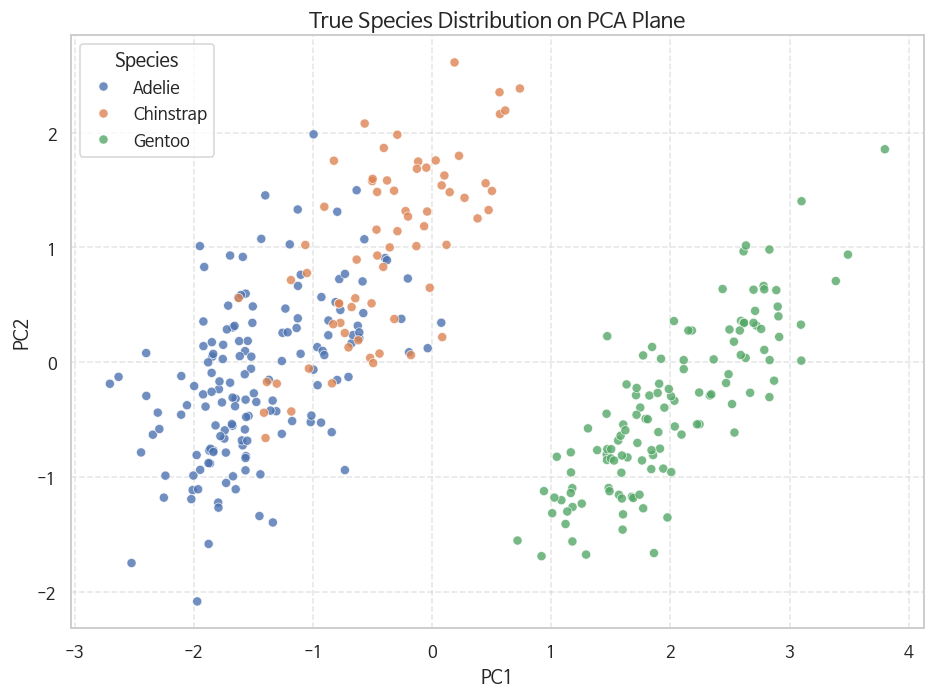

In [27]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. K-Means 결과와 실제 종(Species) 비교
print("=== K-Means vs True Species Crosstab ===")
km_cross = pd.crosstab(y_true, clusters, rownames=['True Species'], colnames=['K-Means Cluster'])
display(km_cross)

km_ari = adjusted_rand_score(y_true, clusters)
km_nmi = normalized_mutual_info_score(y_true, clusters)

# 2. GMM 결과와 실제 종(Species) 비교
print("\n=== GMM vs True Species Crosstab ===")
gmm_cross = pd.crosstab(y_true, gmm_labels, rownames=['True Species'], colnames=['GMM Cluster'])
display(gmm_cross)

gmm_ari = adjusted_rand_score(y_true, gmm_labels)
gmm_nmi = normalized_mutual_info_score(y_true, gmm_labels)

# 3. 최종 성능 지표 요약
performance_summary = pd.DataFrame({
    'Metric': ['ARI (Adjusted Rand Index)', 'NMI (Normalized Mutual Info)'],
    'K-Means': [km_ari, km_nmi],
    'GMM': [gmm_ari, gmm_nmi]
})

print("\n=== Clustering Performance Evaluation ===")
display(performance_summary.round(3))

# 시각적 확인: PCA 평면에서 실제 종 분포
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    hue=y_true,
    palette='deep',
    alpha=0.8
)
plt.title('True Species Distribution on PCA Plane', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== K-Means × Species ===
K-Means       0    1    2
Species(정답)              
Adelie       24    0  127
Chinstrap    63    0    5
Gentoo        0  123    0

=== GMM × Species ===
GMM            0    1   2
Species(정답)              
Adelie       149    0   2
Chinstrap      3    0  65
Gentoo         0  123   0

K-Means  ARI=0.793  NMI=0.786
GMM      ARI=0.960  NMI=0.935


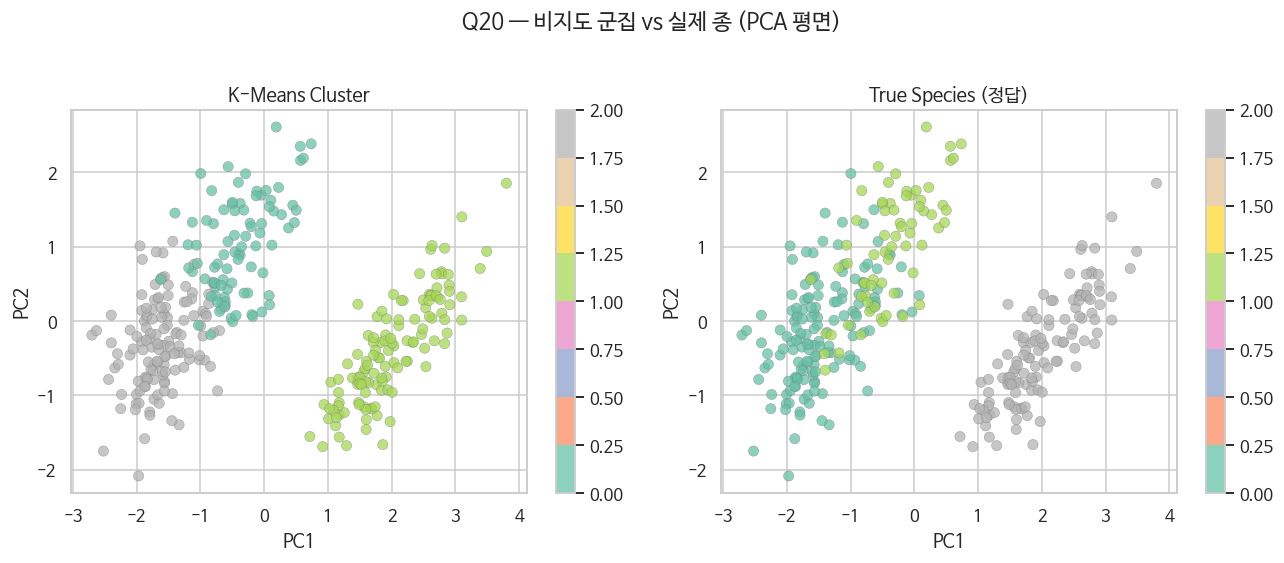

In [ ]:
# 코드

**[결과 해석]**

**오늘의 여정 요약**
1. **PCA** — 분산 보존 선형 축소 (스케일링 필수)
2. **t-SNE** — 비선형 시각화 (transform 불가 주의)
3. **K-Means** — Hard · Elbow · 구형 가정
4. **Silhouette · Dunn** — 레이블 없는 타당성
5. **GMM** — Soft · EM · 타원형 허용
6. **Crosstab** — 숨겨둔 정답과의 최종 대면

LeCun의 **케이크 시트**를 직접 구워 보셨습니다. 다음 시간에는 이 표현 위에 **아이싱(지도학습)** 을 더 얹어 봅시다!

###  참고 문헌 (References)

- 비지도 학습 및 군집 분석의 학술적 토대가 되는 주요 고전 논문 정보와 링크입니다.

- **t-SNE (비선형 차원 축소 및 시각화)**
  * van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research*, 9(11), 2579-2605.
  * [JMLR 공식 저널 웹사이트](https://www.jmlr.org/papers/v9/vandermaaten08a.html) / [공식 원문 PDF 다운로드](https://jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf)

- **Silhouette Index (군집 타당성 평가 지표)**
  * Rousseeuw, P. J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65.
  * [ScienceDirect 저널 웹사이트](https://doi.org/10.1016/0377-0427(87)90125-7) / [KU Leuven 대학 아카이브 PDF](https://wis.kuleuven.be/stat/robust/papers/publications-1987/rousseeuw-silhouettes-jcam-sciencedirectopenarchiv.pdf)

- **Dunn Index (군집 밀집도 및 분리도 평가)**
  * Dunn, J. C. (1974). Well-separated clusters and optimal fuzzy partitions. *Journal of Cybernetics*, 4(1), 95-104.
  * [Taylor & Francis 온라인 웹사이트](https://doi.org/10.1080/01969727408546059) / [Semantic Scholar 서지 정보](https://www.semanticscholar.org/paper/Well-Separated-Clusters-and-Optimal-Fuzzy-Dunn/0a706d920bb542aa5b8dc964e41283bf6652c3a7)

- **EM Algorithm / GMM (가우시안 혼합 모델 및 기댓값 극대화 알고리즘)**
  * Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum likelihood from incomplete data via the EM algorithm. *Journal of the Royal Statistical Society: Series B (Methodological)*, 39(1), 1-22.
  * [Oxford Academic 저널 웹사이트](https://doi.org/10.1111/j.2517-6161.1977.tb01600.x) / [하버드 대학교 DASH 아카이브 PDF](https://dash.harvard.edu/entities/publication/73120378-8486-6bd4-e053-0100007fdf3b)